In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Supermart Grocery-checkpoint.csv')
df.head()


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB


In [4]:
df.isnull().sum().sum()

np.int64(0)

Descriptive Statistics: Calculate basic statistics (mean, median, mode, standard deviation)

In [48]:
df.describe()

,Sales,Discount,Profit
count,9994.000000,9994.000000,9994.000000
mean,1496.596158,0.226817,374.937082
std,577.559036,0.074636,239.932881
min,500.000000,0.100000,25.250000
25%,1000.000000,0.160000,180.022500
50%,1498.000000,0.230000,320.780000
75%,1994.750000,0.290000,525.627500
max,2500.000000,0.350000,1120.950000


In [10]:
df["Order ID"].duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='object')

Visualization: Present insights through bar charts, line plots, and heatmaps.


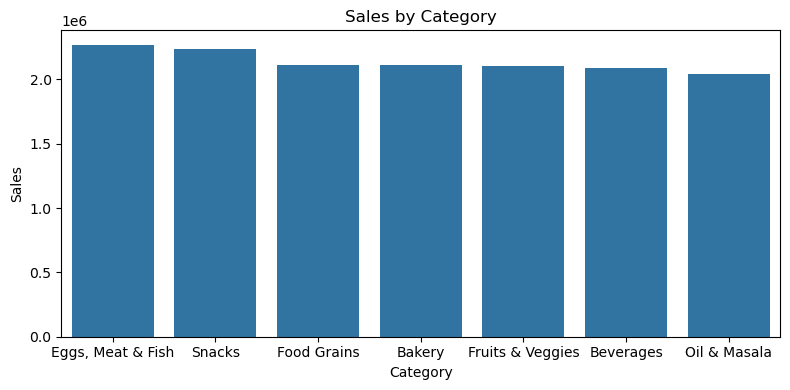

In [5]:

    plt.figure(figsize=(8,4))
    cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
    sns.barplot(y=cat_sales.values, x=cat_sales.index)
    plt.title('Sales by Category')
    plt.ylabel('Sales')
    plt.xlabel('Category')
    plt.tight_layout()
    plt.show()


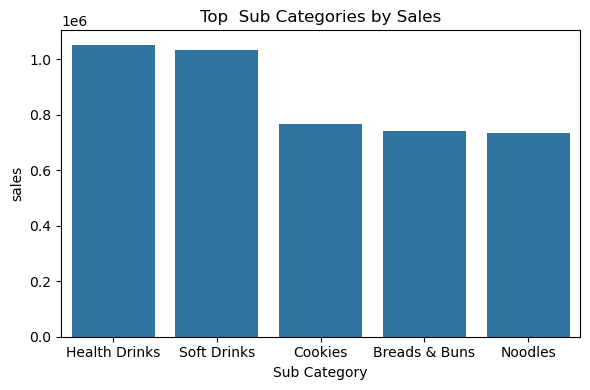

In [6]:
sc = df.groupby('Sub Category')['Sales'].sum().sort_values(ascending=False).head()
plt.figure(figsize=(6,4))
sns.barplot(y=sc.values, x=sc.index)
plt.title(f'Top  Sub Categories by Sales')
plt.xlabel('Sub Category')
plt.ylabel('sales')
plt.tight_layout()
plt.show()

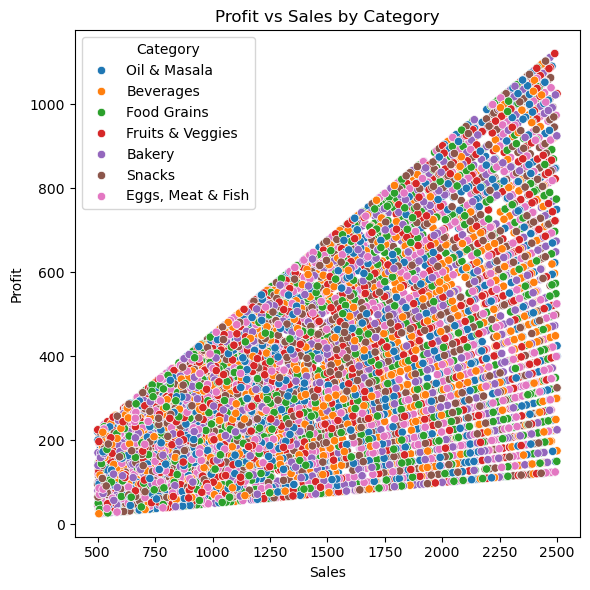

In [10]:
plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category')
plt.title('Profit vs Sales by Category')
plt.tight_layout()
plt.show()

C:\Users\vikra\AppData\Local\Temp\ipykernel_25092\1021274149.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\vikra\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


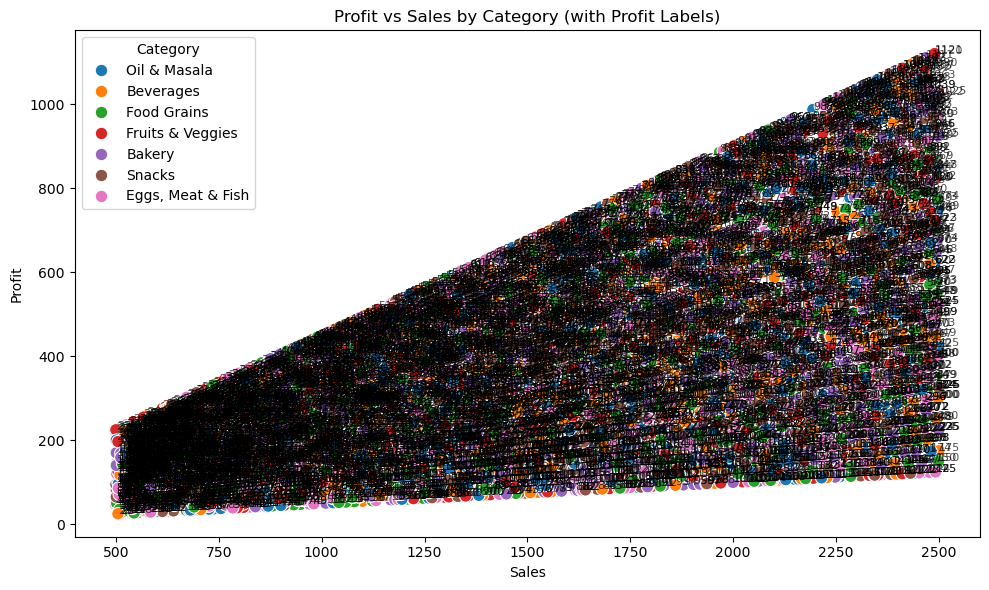

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', s=80)

# Add profit value labels for each point
for i in range(len(df)):
    plt.text(df['Sales'].iloc[i], df['Profit'].iloc[i],
             f"{df['Profit'].iloc[i]:.0f}",  # show profit as integer
             fontsize=8, alpha=0.7)

plt.title('Profit vs Sales by Category (with Profit Labels)')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

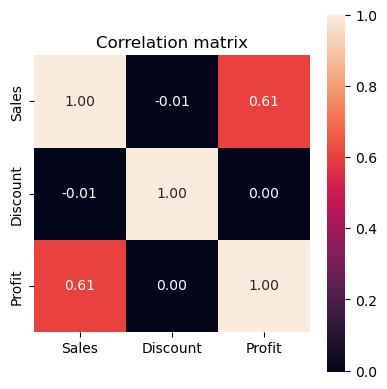

In [9]:
numeric = df[['Sales','Discount','Profit']].copy()
corr = numeric.corr()
plt.figure(figsize=(4,4))
sns.heatmap(corr, annot=True, fmt='.2f', square=True)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

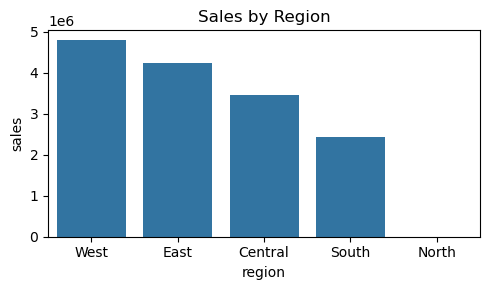

In [41]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(5,3))
sns.barplot(y=region_sales.values, x=region_sales.index)
plt.title('Sales by Region')
plt.xlabel('region')
plt.ylabel('sales')
plt.tight_layout()
plt.show()

RECOMMENDATIONS = '''
Actionable recommendations (example) — adapt to your business context:


1) Focus on high-margin categories: Identify categories with strong Sales but low ProfitMargin. Investigate cost structure, supplier pricing, or discounting in those categories.


2) Engage top customers: Use the top_customers table to run retention campaigns, loyalty offers, or personalized promotions for the highest-value customers.


3) Seasonal planning: Use the monthly time series and seasonal decomposition to prepare inventory and promotions for peak months.


4) Region-specific strategies: If some regions show high sales but low profits, examine shipping, returns, or local pricing differences. Expand successful region strategies to similar cities.


5) Discount effectiveness: Analyze whether higher discounts correlate with negative profit margins at the Sub Category level — avoid blanket discounting; prefer targeted discounts on products with elastic demand.


6) Data quality improvements: Ensure Order Date and Sales are always recorded, standardize City/State naming, and add fields such as Quantity, Product ID, Customer Segment to enable deeper analysis.


7) A/B test promotions: Run controlled experiments to measure uplift from marketing campaigns on a sample of customers or regions before full rollout.


Adapt these recommendations after reviewing the aggregated tables generated above.